# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

# En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [90]:
# Importar librerías
import pandas as pd
from scipy.stats import pointbiserialr
import numpy as np 
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [91]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [92]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual` 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna....
- `visitas_mes`
- `compras_mes

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [93]:
# Corregir el tipo de dato
df["id_cliente"] = df["id_cliente"].astype("category")

In [94]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  category
 1   edad                       15000 non-null  float64 
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  int64   
 8   abandono                   15000 non-null  int64   
 9   tipo_dispositivo           15000 non-null  object  
 10  region                     15000 non-null  object  
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(1), float64(5), int64(4), object(2)
memory usage: 1.9+ MB


#### Explorar variables numéricas

In [95]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` promedio de 38 años.
- `nivel_ingreso` nivel promedio de 30019 y un maixmo de 74790.
- `gasto_publicidad_dirigida` el 50% de los usuarios recibe entre 0 y 1 impacto publicitario
- `ingreso_anual` valores atipocos, promedio de 36.59 pero un max de 244.69

#### Explorar variables binarias

In [96]:
# Verificar que cada columna tenga únicamente dos valores posibles

print(df["miembro_premium"].unique())
print(df["abandono"].unique())


[0 1]
[0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — No hay valores atipocos, string o nan
- `abandono` — No hay valores atipocos, string o nan

#### Explorar variables categóricas

In [97]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ["id_cliente","tipo_dispositivo","region"]
df[columnas_categoricas].nunique()

id_cliente          15000
tipo_dispositivo        3
region                  4
dtype: int64

In [98]:
# Explorar variables categóricas y cómo se distribuyen
print("Distribucion")
print("Regio")

print(df["tipo_dispositivo"].value_counts())
print(df["region"].value_counts())


Distribucion
Regio
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo`vemos 3 tipos de dispositivos, siendo movil el 65% del total.
- `Distribucion` una distribucion muy pareja. Siendo "este" el que se queda un poco atras.
-

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

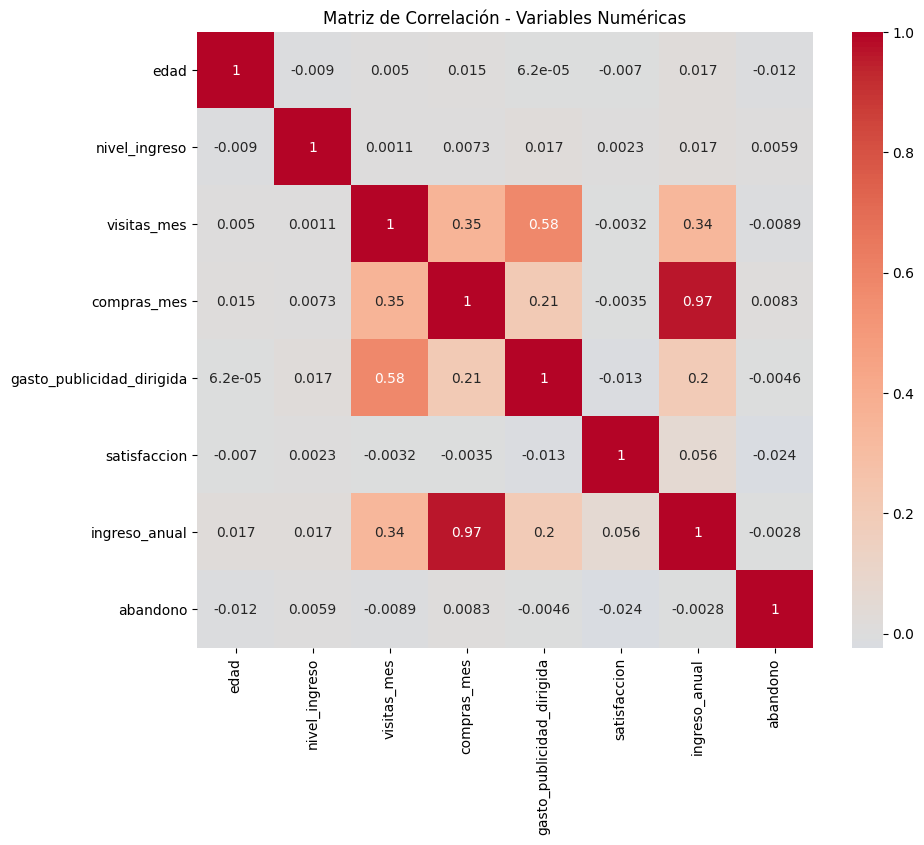

In [99]:
# Visualizar la matriz de correlación para identificar relaciones
cols_interes = ["edad","nivel_ingreso","visitas_mes","compras_mes","gasto_publicidad_dirigida","satisfaccion","ingreso_anual","abandono"]

corr_matriz = df[cols_interes].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz,annot=True,cmap='coolwarm',center=0,square=True)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa ... La correlacion mas fuerte es entre "ingreso anual" y "compras_mes" de 0.97. Correlacion moderada entre "vistas_mes" y "gasto_publicidad_dirigida" de 0.58. En su mayoria se muentran correlaciones cercanas al cero.

Observaciones respecto a `ingreso_anual`  
- Presenta... Con la correlacion tan fuerte con las compras, se toma en cuenta el ingreso anual como la columna clave, para cualquier modelo a predecir. Tambien tiene una correlacion moderada con "vistas" con 0.34 y no influye en categorias como abandono, significando que pa perdida de un cliente no necesariamente tiene que ver con su niver economico.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**: debe incluirse un scatterplot de "ingreso_anual" y "compras_mes", por que describe visualmente la relacion entre ellas y valida el dato.
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.
    Se confirma la correlacion entre "ingreso_anual" y "compras_mes".
    
- **Si decides no incluirlo**:
  - Explica por qué.

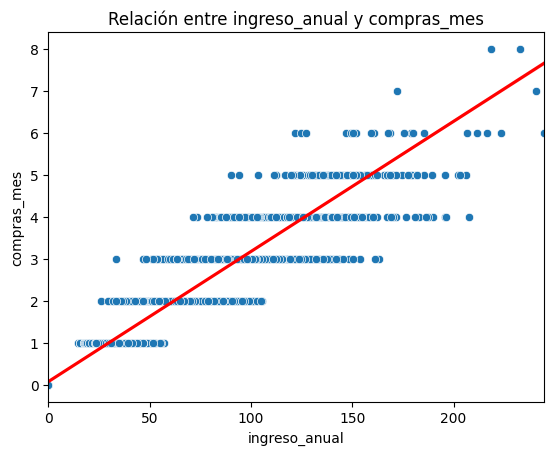

In [100]:
sns.scatterplot(data=df,x="ingreso_anual", y="compras_mes")
sns.regplot(data=df, x='ingreso_anual', y='compras_mes',
    scatter=False, color='red')

plt.title("Relación entre ingreso_anual y compras_mes")
plt.xlabel("ingreso_anual")
plt.ylabel("compras_mes")
plt.show()

### Scatterplot para pares clave

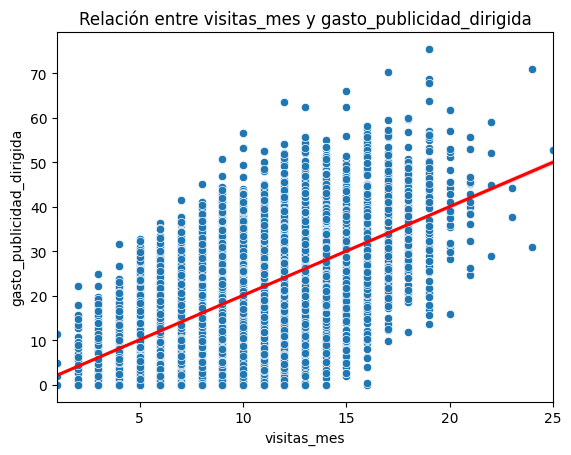

In [101]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df,x="visitas_mes", y="gasto_publicidad_dirigida")
sns.regplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida',
    scatter=False, color='red')

plt.title("Relación entre visitas_mes y gasto_publicidad_dirigida")
plt.xlabel("visitas_mes")
plt.ylabel("gasto_publicidad_dirigida")
plt.show()

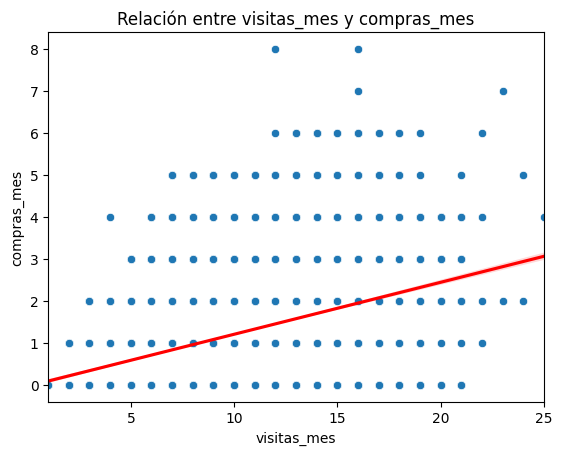

In [102]:

sns.scatterplot(data=df,x="visitas_mes", y="compras_mes")
sns.regplot(data=df, x='visitas_mes', y='compras_mes',
    scatter=False, color='red')

plt.title("Relación entre visitas_mes y compras_mes")
plt.xlabel("visitas_mes")
plt.ylabel("compras_mes")
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot):
El analisis revela que las estrategias de publicidad dirigida tiene una efectividad moderada y se muestra tambien una dispercion significativa entre visitas y compras efectivas.

**var1 vs var2**
- Dirección ... Positiva
- Dispercion ... Media
- Presencia de Outliers ... Se ven algunos puntos dispersos en la parte superior.
- Posible Colinealidad ... Moderada

**var1 vs var3**
- Dirección ... Positiva
- Dispercion ... Alta
- Presencia de Outliers ... Se ven puntos en la parte superior que representan a los clientes mas activos.
- Posible Colinealidad ... Baja

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [131]:
# Calcular correlación entre variables relevantes
pearson_ingreso_compras = df["ingreso_anual"].corr(df["compras_mes"],method="pearson")
print(f"Coeficiente de Pearson (Ingresos vs Compras):{pearson_ingreso_compras:.4f}")

Coeficiente de Pearson (Ingresos vs Compras):0.9671


In [132]:
# Calcular correlación entre variables relevantes
spearman_visitas_compras = df["visitas_mes"].corr(df["compras_mes"],method="pearson")
print(f"Coeficiente de Pearson (visitas_mes vs Compras):{spearman_visitas_compras:.4f}")

Coeficiente de Pearson (visitas_mes vs Compras):0.3538


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- Correlación ... direccion positiva del 0.97 es una magnitud fuerte y positiva, sugiriendo que el ingreso es lo que mueve las compras. Y una colinealidad muy alta.

**var2 vs var3**
- Correlación ... direccion positiva y magnitud moderada, con escasa colinealidad, lo que sugiere que muchas vistas no garantizan mas compras.
- 

### Punto-biserial

In [133]:
# Calcular correlación entre variables relevantes
corr_biserial,_= pointbiserialr(df["satisfaccion"],df["abandono"])       
print(f"Correlacion Point-Biserial(satisfaccion vs abandono):{corr_biserial:.4f}")

Correlacion Point-Biserial(satisfaccion vs abandono):-0.0238


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- Relación ... Correlacion negativa, magnitud baja.

**var2 vs var3**
- Relación ...

### V de Cramér

In [134]:
# Función para calcular V de Cramér
#def cramer_v(df, col1, col2):
    # tabla de contingencia
    #tabla = pd.crosstab(df[col1], df[col2])
    
    # calcular chi-cuadrado
   # chi2, p_value, dof, expected = chi2_contingency(tabla)
    
    # calcular coeficiente V de Cramér
   # n = tabla.values.sum()
    #v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    
    #return v

In [135]:
# Aplicar V de Cramér en variables relevantes
v_region_premium = cramer_v(df,"region","miembro_premium")
v_dispositivo_premium = cramer_v(df,"tipo_dispositivo","miembro_premium")

print(f"V de Cramer (Region vs Premium):{v_region_premium:.4f}")
print(f"V de Cramer (Dispositivo vs Premium):{v_dispositivo_premium:.4f}")    
  


V de Cramer (Region vs Premium):0.0126
V de Cramer (Dispositivo vs Premium):0.0197


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
Ambas relaciones son practicamente nulas, tanto la region como el tipo de dispositivo no tienen ninguna preferencia a lo que respecta ser premium.


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — 
La relacion entre ingreso anual y compras mes es la mas dominante.

**Evidencia visual:**
El scatterplot muestra una linea diagonal ascendente casi perfecta con minima dispersion.

**Evidencia numérica:** 
El coeficiente de Pearson de 0.97, indica la relacion lineal positiva y fuerte.

**Interpretación**  
El numero de transacciones mensuales esta determinado directamente por la capacidad economina del cliente.

**No podemos afirmar**  
Sabemos que ambos crecen juntos, pero no podemos afirmar que el cliente use mas la plataforma solo por esto.

**Implicación de negocio**  
Priorizar la atencion de perfiles de ingresos altos para asegurar volumen de ventas.

### Hallazgo 2 — 
Eficiencia de gastos publicitarios en la atraccion de clientes.

**Evidencia visual:**   
El scatterplot entre gasto de publicidad y visitas al mes, muestra una tendencia positiva. Con algunos puntos dispersos en la parte superior.

**Evidencia numérica:** 
Coeficiente de Pearson de 0.58, siendo una relacion moderada con tendencia a fuerte.

**Interpretación**  
La publicidad esta dando buen resultado, atrayendo gente a las tiendas digitales.

**No podemos afirmar**  
No podemos afirmar que toda la publicidad esta ciendo efectiva. Ya que la dispercion que vemos en la grafica, habla de publicidad sin el mismo exito.

**Implicación de negocio**  
Existe un retorno claro por parte de la publicidad, mantener o escalar el presupuesto podria ser el paso a seguir, pero revisando donde esta fallando para reducir los puntos de dispercion.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad

Es importante ascentuar que una correlacion fuerte como la de ingreso anual y compras por mes de 0.97, no necesariamente implica una causalidad.
Aun que el ingreso y la compra suben juntos, no podemos decir que el ingreso es la unica causa de las compras. 

Tambien resaltar limitaciones como variables categoricas casi nulas, sesgo de variables o limitacion de datos, no contamos con datos de otros años para ver un panorama mas amplio.

### **Próximos pasos** 

Probar segmentación adicional
- Variar los insentivos de compra, para diferencial el nivel de ingreso y medir una respuesta real, llendo mas haya de la correlacion.
- Usar las variables con mayor correlacion, para crear un modelo de machine Learning, que nos de un panorama de posibilidades de conversion de nuevos usuarios.

- Recolectar informacion en base a entrevistas a usuarios con altas visitas pero sin compras. Ver los motivos por los cuales no se esta llegando a la compra final.
- Integrar nuevas herramientas al dataset, como datos sobre las tiendas en linea, el tiempo en la pagina, efectividad de banners, niveles donde se pueda quedar estancado el usuario, etc. Para fortalecer el analisis del ambudo de ventas.
